In [1]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [17]:
# 종속 변수와 예측 결과로 혼동 행렬 생성
from sklearn.metrics import confusion_matrix

# 혼동 행렬 생성
cm = confusion_matrix(y, y_pred)

print("혼동 행렬(오차 행렬):")
print(cm)

혼동 행렬(오차 행렬):
[[337  20]
 [ 30 182]]


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)
     

Accuracy: 0.9121265377855887


**정밀도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [15]:
from sklearn.metrics import precision_score

precision = precision_score(y, y_pred)
print("Precision:", precision)

Precision: 0.900990099009901


정밀도 <br>
- 정밀도 = TP / (FP + TP)
- 예측을 positive로 한 대상 중에 예측과 실제 값이 Positive로 일치한 데이터들의 비율 
- 정밀도 0.901 모델 예측이 충분히 신뢰할만 함을 알 수 있다.

**재현율의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

재현율은 모델이 실제로 악성인 데이터 중에서, 악성이라고 올바르게 예측한 비율 <br>
재현율 0.8585는 모델이 실제 악성 샘플 중 약 86%를 올바르게 감지했지만, 일부(약 14%)는 놓쳤음을 알 수 있다

In [19]:
from sklearn.metrics import recall_score

recall = recall_score(y, y_pred)
print("Recall:", recall)
     

Recall: 0.8584905660377359


**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

정밀도와 재현율을 결합한 지표

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y, y_pred)
print("F1:", f1)

**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [ ]:
from sklearn.preprocessing import Binarizer

y_proba = model_lor.predict_proba(X)
y_proba_0 = y_proba[:, 0].reshape(-1, 1)  

binarizer = Binarizer(threshold=0.1)
y_pred2_temp = binarizer.transform(y_proba_0)
y_pred2 = 1 - y_pred2_temp.flatten()

print(y_pred2[:10])


[1. 1. 1. 0. 1. 0. 1. 0. 0. 0.]


In [16]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 혼동행렬
cm = confusion_matrix(y, y_pred2)
print("혼동행렬:\n", cm)

# 정확도
accuracy = accuracy_score(y, y_pred2)
print("\n정확도:", accuracy)

# 정밀도
precision = precision_score(y, y_pred2)
print("정밀도:", precision)

# 재현율
recall = recall_score(y, y_pred2)
print("재현율:", recall)

# F1 점수
f1 = f1_score(y, y_pred2)
print("F1 점수:", f1)

혼동행렬:
 [[356   1]
 [ 72 140]]

정확도: 0.8717047451669596
정밀도: 0.9929078014184397
재현율: 0.660377358490566
F1 점수: 0.7932011331444759


**ROC 곡선 시각화**

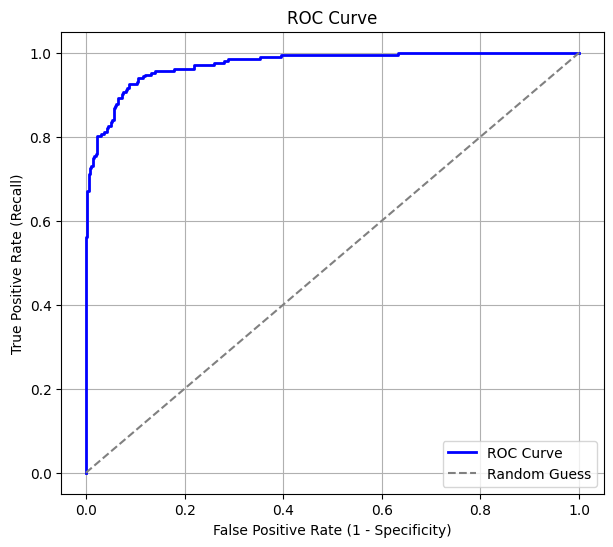

In [21]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# 예측 확률 (클래스 1, 악성일 확률)
y_proba = model_lor.predict_proba(X)[:, 1]

# ROC 곡선 계산
fpr, tpr, thresholds = roc_curve(y, y_proba)

# 시각화
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC Curve')
plt.plot([0,1], [0,1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt


**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [22]:
from sklearn.metrics import roc_auc_score

# 예측 확률
y_proba = model_lor.predict_proba(X)[:, 1]

# AUC 계산
auc_score = roc_auc_score(y, y_proba)
print("ROC AUC:", auc_score)


ROC AUC: 0.9733232915807832
